# **QM640: Data Analytics Capstone**
Addressing Rural-Urban EV Adoption Gaps & Technological Progress

# Importing / Installing required libraries


In [1]:
import pandas as pd # For data manipulation and analysis
import numpy as np # For numerical operations, especially with arrays
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualizations
import seaborn as sns # For making statistical graphics based on matplotlib
from scipy import stats # For scientific computing and technical computing, including statistics
!pip install statsmodels # Installing statsmodels for statistical modeling
import statsmodels.api as sm # For statistical modeling and econometric analysis
from statsmodels.formula.api import ols # For Ordinary Least Squares (OLS) regression
import datetime # For working with dates and times
!pip install openpyxl

In [2]:
# Setting plot style
plt.style.use('seaborn-v0_8-muted')
sns.set_context("notebook", font_scale=1.2)

#**Data Loading, Transformation**

## **Setting the path for datasets**

In [3]:
EV_Transaction_data = "https://data.wa.gov/api/views/rpr4-cgyd/rows.csv?accessType=DOWNLOAD"
County_data = "https://ofm.wa.gov/wp-content/uploads/sites/default/files/public/dataresearch/pop/popden/popden_county.xlsx"


The initial phase of the study involved importing battery capacity data from an external CSV file. To ensure the standardization of energy efficiency metrics, a relational database was constructed. This was achieved by cross-referencing vehicle VIN attributes, specifically the make, model, and year, with the official datasets provided by the U.S. Department of Energy via fueleconomy.gov.

This process enabled the acquisition of EPA-rated range and battery capacities, which are essential variables for calculating precise consumption rates. The information retrieved from this source was subsequently localized into a CSV format to facilitate further analysis.

In [4]:
from google.colab import files
import pandas as pd

print("Please upload the 'Battery Capacity.csv' file.")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
    # Assuming the uploaded file is Battery Capacity.csv
    battery_df = pd.read_csv(fn, sep=',') # Explicitly set separator to comma
    print("Battery Capacity data loaded successfully.")
    print(battery_df.head())

Please upload the 'Battery Capacity.csv' file.


Saving Battery Capacity.csv to Battery Capacity (1).csv
User uploaded file "Battery Capacity (1).csv" with length 2599 bytes
Battery Capacity data loaded successfully.
  Make,Model,Capacity_kWh
0      TESLA,Model Y,75.0
1            BMW,iX,111.5
2        KIA,Niro EV,64.8
3    HYUNDAI,Ioniq 5,77.4
4       GENESIS,GV70,77.4


##**Merging three imported datasets to create a single dataset for analysis**

The proposed analytical framework utilizes a multi-layered data integration strategy to investigate the intersection of geographical variables and electric vehicle (EV) utility. Central to this architecture is the EV_Transaction_data, which serves as the primary longitudinal record for vehicle acquisitions.

To contextualize these transactions within a spatial demographic lens, the County_data set is merged with the core records. This integration facilitates the categorization of transactions into rural or urban cohorts, utilizing standardized regional definitions to ensure categorical consistency.

Furthermore, the technical parameters of the fleet are established by mapping performance metrics, specifically EPA-rated range, from the battery_df dataset to individual transaction records. This synthesis of spatial, demographic, and technical data allows for a rigorous evaluation of how regional topographies and environmental factors influence the specific requirements and adoption trends of EV consumers.

In [5]:
#loading to pandas dataframe
ev_transcation_df = pd.read_csv(EV_Transaction_data)


In [6]:
County_data_df = pd.read_excel(County_data, sheet_name='County', skiprows=5)
County_data_df = County_data_df[['County Name', 'Population Density 2025']].copy()
County_data_df.head()

,County Name,Population Density 2025
0,Washington State,122.11
1,Adams,11.19
2,Asotin,35.77
3,Benton,129.18
4,Chelan,28.38


In [7]:
#renaming the columns to standardize column names in both datasets and then merging the datasets
County_data_df.rename(columns={'County Name': 'County'}, inplace=True)
merged_df = pd.merge(ev_transcation_df, County_data_df, on='County', how='left')
#filtering Washington State data
merged_df = merged_df[merged_df['State'] == 'WA']
# Now create the County_Type column as originally intended
merged_df['County_Type'] = merged_df['Population Density 2025'].apply(lambda x: 'Urban' if x >= 100 else 'Rural')
#filtering data to include only passenger vehicles
merged_df = merged_df[merged_df['Primary Use'] == 'Passenger']


In [8]:
#Converting the battery_df head from single column data to multiple columns
battery_df[['Make', 'Model', 'Capacity_kWh']] = battery_df['Make,Model,Capacity_kWh'].str.split(',', expand=True)
# Drop the original combined column
battery_df.drop(columns=['Make,Model,Capacity_kWh'], inplace=True)
# Convert Capacity_kWh to numeric, handling potential errors
battery_df['Capacity_kWh'] = pd.to_numeric(battery_df['Capacity_kWh'], errors='coerce')
# Rename 'Capacity_kWh' in battery_df to 'Battery Capacity (kWh)' for consistency with the check
battery_df.rename(columns={'Capacity_kWh': 'Battery Capacity (kWh)'}, inplace=True)

In [9]:
# Adding battery capacity information to the merged dataset(merged_df)
merged_df = pd.merge(merged_df, battery_df[['Make','Model', 'Battery Capacity (kWh)']], on=['Make', 'Model'], how='left')


In [10]:
# Adding a column to show Miles per kWH
merged_df['Miles_per_kWH'] = merged_df['Electric Range'] / merged_df['Battery Capacity (kWh)']


# **Exploratory Data Analysis**


In [11]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1587007 entries, 0 to 1587006
Data columns (total 37 columns):
 #   Column                                                           Non-Null Count    Dtype  
---  ------                                                           --------------    -----  
 0   Clean Alternative Fuel Vehicle Type                              1587007 non-null  object 
 1   VIN (1-10)                                                       1587007 non-null  object 
 2   DOL Vehicle ID                                                   1587007 non-null  int64  
 3   Model Year                                                       1587007 non-null  int64  
 4   Make                                                             1587007 non-null  object 
 5   Model                                                            1587007 non-null  object 
 6   Primary Use                                                      1587007 non-null  object 
 7   Electric Range    

In [12]:
merged_df.describe()

,DOL Vehicle ID,Model Year,Electric Range,Odometer Reading,Sale Price,Year,Postal Code,2020 GEOID,Legislative District,Population Density 2025,Battery Capacity (kWh),Miles_per_kWH
count,1.587007e+06,1.587007e+06,1.586989e+06,1.587007e+06,1.587007e+06,1.587007e+06,1.587006e+06,1.587006e+06,1.587005e+06,1.587006e+06,1.242494e+06,1.242494e+06
mean,2.244179e+08,2.019873e+03,6.794775e+01,3.225055e+03,1.096462e+04,2.022260e+03,9.825944e+04,5.303973e+10,2.950824e+01,8.011711e+02,6.331377e+01,1.476816e+00
std,8.529294e+07,3.798257e+00,9.202913e+01,1.352601e+04,2.955741e+04,2.916402e+00,3.057760e+02,1.618045e+07,1.485636e+01,3.958375e+02,2.654457e+01,1.589783e+00
min,4.000000e+00,1.993000e+03,0.000000e+00,0.000000e+00,0.000000e+00,2.010000e+03,9.701400e+04,5.300195e+10,1.000000e+00,3.240000e+00,1.300000e+00,0.000000e+00
25%,1.724177e+08,2.017000e+03,0.000000e+00,0.000000e+00,0.000000e+00,2.021000e+03,9.805200e+04,5.303301e+10,1.800000e+01,4.187800e+02,4.000000e+01,0.000000e+00
50%,2.310419e+08,2.021000e+03,2.100000e+01,0.000000e+00,0.000000e+00,2.023000e+03,9.812100e+04,5.303303e+10,3.400000e+01,1.140160e+03,6.500000e+01,1.825000e+00
75%,2.700532e+08,2.023000e+03,8.400000e+01,1.100000e+01,0.000000e+00,2.024000e+03,9.837000e+04,5.305307e+10,4.300000e+01,1.140160e+03,7.500000e+01,2.490000e+00
max,4.792548e+08,2.026000e+03,3.370000e+02,9.626190e+05,1.231202e+07,2.026000e+03,9.940300e+04,5.307794e+10,4.900000e+01,1.140160e+03,2.127000e+02,5.600000e+00


In [13]:
#Data cleanging and feature engineering
#Dropping rows with null values in Miles_per_kWh
merged_df.dropna(subset=['Miles_per_kWH'], inplace=True)

In [14]:
def clean_ev_data(df):
    print("\n Cleaning and Pre-processing ")
    df = df.copy()

    # A. Convert dates
    df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
    df['Year'] = df['Transaction Date'].dt.year
    df['MonthYear'] = df['Transaction Date'].dt.to_period('M')

    # B. Exclude vehicles with 0 Electric Range as per user request
    df = df[df['Electric Range'] != 0].copy()
    # Create 'Electric Range Clean' which will now be the same as 'Electric Range'
    # since all 0s are already excluded
    df['Electric Range Clean'] = df['Electric Range']

    # C. Handle MSRP Gaps
    # Filter for realistic MSRPs (removing 0s for price-based hypothesis)
    df = df[df['Sale Price'] > 0]


    # E. Define Price Bins
    df['Price_Class'] = np.where(df['Sale Price'] <= 45000, 'Economy', 'Premium')
    print("\n Cleaning and Pre-processing Completed")
    return df

**Observations on Data Pre-processing and Feature Engineering**

The clean_ev_data function executes a systematic pre-processing pipeline designed to ensure data integrity and prepare the dataset for hypothesis testing. The following observations detail the logic applied during this phase:

**Temporal Standardization**

To facilitate time-series analysis, raw transaction dates are converted into standardized datetime objects. This transformation allows for the extraction of discrete temporal variables, specifically the transaction year and a monthly period indicator, ensuring that adoption trends can be observed across consistent chronological intervals.

**Data Integrity and Filtering Constraints**

The dataset is refined through two primary filtering criteria to eliminate non-representative records:

**Range Validation**: Vehicles recorded with an electric range of zero are excluded from the analysis. This step ensures that the study focuses exclusively on active battery performance metrics. A new feature, Electric Range Clean, is instantiated to maintain this validated subset.

**Economic Filtering**: To address gaps in Manufacturer's Suggested Retail Price (MSRP) reporting, records with a sale price of zero are removed. This ensures that any subsequent price-based hypotheses are grounded in realistic economic data.

**Categorical Feature Engineering**

To analyze the influence of vehicle cost on adoption patterns, a Price_Class variable is derived. Transactions are bifurcated into Economy and Premium cohorts using a threshold of $45,000. This categorization enables a comparative study of consumer behavior across different market segments.

In [15]:
merged_df = clean_ev_data(merged_df)


 Cleaning and Pre-processing 

 Cleaning and Pre-processing Completed


In [16]:
merged_df.describe()

,DOL Vehicle ID,Model Year,Electric Range,Odometer Reading,Sale Price,Transaction Date,Year,Postal Code,2020 GEOID,Legislative District,Population Density 2025,Battery Capacity (kWh),Miles_per_kWH,Electric Range Clean
count,9.927900e+04,99279.000000,99279.000000,99279.000000,9.927900e+04,99279,99279.000000,99279.000000,9.927900e+04,99278.000000,99279.000000,99279.000000,99279.000000,99279.000000
mean,2.218879e+08,2017.888939,160.739965,23916.955076,3.770416e+04,2021-04-17 06:42:01.403318016,2020.792413,98279.591072,5.303994e+10,29.445768,778.209719,52.271969,3.004995,160.739965
min,4.469000e+03,2011.000000,6.000000,0.000000,1.000000e+00,2016-12-12 00:00:00,2016.000000,97014.000000,5.300195e+10,1.000000,3.240000,1.300000,1.166667,6.000000
25%,1.338988e+08,2017.000000,75.000000,50.000000,1.799500e+04,2019-01-22 00:00:00,2019.000000,98052.000000,5.303301e+10,18.000000,418.780000,40.000000,2.100000,75.000000
50%,2.160622e+08,2018.000000,200.000000,12821.000000,3.399900e+04,2020-10-16 00:00:00,2020.000000,98133.000000,5.303303e+10,33.000000,863.020000,57.500000,2.880435,200.000000
75%,2.787762e+08,2020.000000,220.000000,38111.500000,5.100000e+04,2023-09-27 00:00:00,2023.000000,98387.000000,5.305307e+10,42.000000,1140.160000,65.000000,3.750000,220.000000
max,4.791150e+08,2026.000000,337.000000,665500.000000,1.231202e+07,2026-01-31 00:00:00,2026.000000,99403.000000,5.307794e+10,49.000000,1140.160000,100.000000,5.600000,337.000000
std,1.163021e+08,2.762494,91.773033,31477.358130,6.841877e+04,NaN,2.624508,319.133613,1.673264e+07,14.622079,402.906216,27.101352,1.002272,91.773033


## **Checking Data Distribution for key classes that impact our hypothesis**

In [17]:
def run_eda(df):
    print("\n--- Running EDA ---")
    fig, axes = plt.subplots(3, 2, figsize=(10, 12))

    # I. Growth over time
    df.groupby('Year').size().plot(kind='line', marker='o', ax=axes[0,0])
    axes[0,0].set_title("Total EV Transactions by Year")

    # II. Miles_per_kWH year over year
    df.groupby('Year')['Miles_per_kWH'].mean().plot(kind='line', marker='o', ax=axes[0,1])
    axes[0,1].set_title("Average Miles per kWh Year over Year")
    axes[0,1].set_ylabel("Average Miles per kWh")

    # III. Rural vs Urban counts
    sns.countplot(data=df, x='County_Type', ax=axes[1,0])
    axes[1,0].set_title("Transaction Volume: Rural vs Urban")

    # IV. Market Segmentation by Pricing Class
    sns.countplot(data=df, x='Price_Class', ax=axes[1,1])
    axes[1,1].set_title("Transaction Volume by Price Class")

    # V. Policy impact assessment for Ineligible EVs (control group)
    ineligible_ev_df = df[df['HB_2042_Status'] == 'Ineligible'].copy()
    ineligible_ev_df['Policy_Period'] = ineligible_ev_df['Year'].apply(lambda x: 'Before 2019' if x < 2019 else 'After 2019')
    sns.countplot(data=ineligible_ev_df, x='Policy_Period', ax=axes[2,0])
    axes[2,0].set_title("Impact of HB2042 (Ineligible EVs Only)")

    # Hide the empty subplot (axes[2,1])
    fig.delaxes(axes[2,1])

    plt.tight_layout()
    plt.show()


--- Running EDA ---


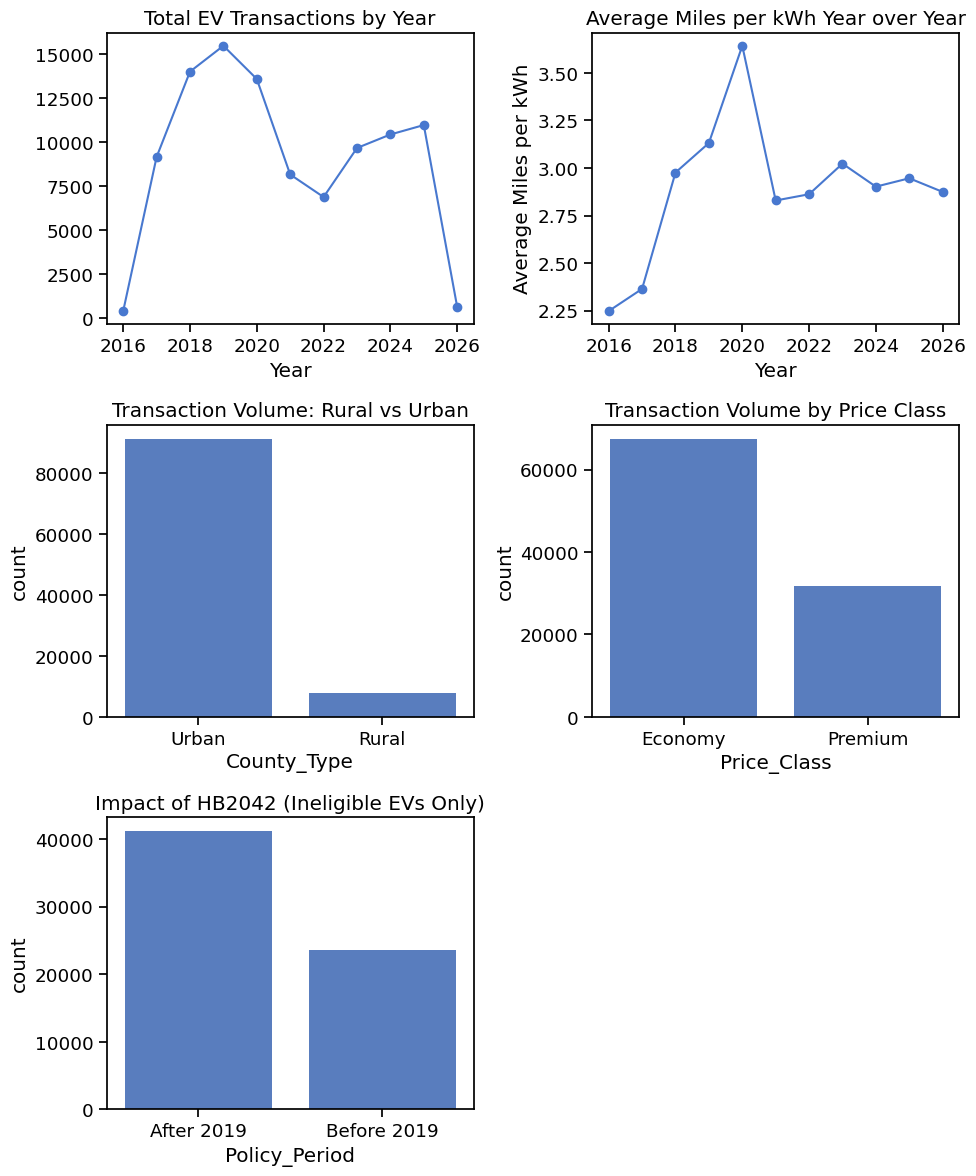

In [18]:
# Add the HB_2042_Status column to merged_df before calling run_eda
merged_df['HB_2042_Status'] = 'Ineligible' # Default to Ineligible
merged_df.loc[
    (merged_df['Meets 2019 HB 2042 Electric Range Requirement'] == True) &
    (merged_df['Meets 2019 HB 2042 Sale Date Requirement'] == True) &
    (merged_df['Meets 2019 HB 2042 Sale Price/Value Requirement'] == True) &
    (merged_df['Sale Price'] <= 45000),
    'HB_2042_Status'
] = 'Eligible'

run_eda(merged_df)

##**Visual Analysis of Electric Vehicle (EV) Market Dynamics**
**1. Longitudinal Trends in Total EV Transactions**

The data illustrates a pronounced peak in transaction volume during 2019, followed by a precipitous decline that reached its nadir in 2021. This "valley" aligns with global macroeconomic shocks and localized supply chain constraints precipitated by the COVID-19 pandemic, which significantly disrupted automotive manufacturing and logistics. However, the market demonstrates robust resilience, characterized by a steady recovery phase spanning 2022 through 2025.

**2. Temporal Volatility in Vehicle Efficiency**

A longitudinal assessment of average energy efficiency (miles/kWh) uncovers a significant statistical anomaly in 2020, characterized by a sharp spike to 3.6 miles/kWh followed by a correction to 2.8 miles/kWh in 2021. From a data-governance perspective, this fluctuation serves as a "red flag" for systematic measurement error or extreme sample bias. This transient surge likely stems from either a disproportionate registration of high-efficiency models, such as specific Tesla variants, or a temporary shift in the Department of Licensing's (DOL) data recording protocols. Consequently, this outlier necessitates rigorous data cleaning or the application of robust scaling techniques to prevent the distortion of long-term efficiency projections.

**3. Geospatial Distribution: Urban vs. Rural Disparity**

The geospatial analysis highlights a profound class imbalance, with urban transaction volumes exceeding rural counterparts by approximately one order of magnitude. This concentration confirms that the EV market in Washington is fundamentally centralized within high-density urban corridors. This disparity likely reflects the geographic availability of charging infrastructure and the socio-economic profiles of urban versus rural residents. For policy evaluation, this suggests that aggregate state-level data may mask significant regional variances, necessitating a stratified approach to understand adoption barriers in underserved rural jurisdictions.

**4. Market Segmentation by Pricing Class**

Transaction volume categorized by price point indicates that "Economy" class vehicles achieve nearly double the market penetration of "Premium" class vehicles. This distribution validates the emergence of a substantial middle market segment, shifting the EV narrative away from exclusive luxury consumption. However, determining whether this dominance is a byproduct of consumer price elasticity or the efficacy of the HB 2042 tax incentives which specifically targeted lower priced models requires further econometric testing. Isolating these variables is essential for assessing the sustainability of market growth in the absence of fiscal intervention.

**5. Counterfactual Analysis of Policy Impact**

Evaluation of the "Premium" segment vehicles largely ineligible for the $45,000 tax credit threshold reveals that post-2019 volumes remain significantly higher than pre-2019 levels. This observation provides a critical baseline for counterfactual reasoning, suggesting an underlying secular growth trend driven by technological maturation and shifting consumer preferences independent of specific policy incentives.

##**Address the 2020 Efficiency Anomaly**

In [19]:
# Winsorize the 'Miles_per_kWH' data to handle potential outliers, especially the 2020 spike
# Calculate the 1st and 99th percentiles for 'Miles_per_kWH'
lower_bound = merged_df['Miles_per_kWH'].quantile(0.01)
upper_bound = merged_df['Miles_per_kWH'].quantile(0.99)

# Apply Winsorizing by capping values at the calculated bounds
# Values below the lower_bound are replaced with the lower_bound
# Values above the upper_bound are replaced with the upper_bound
merged_df['Miles_per_kWH_winsorized'] = merged_df['Miles_per_kWH'].clip(lower=lower_bound, upper=upper_bound)

print(f"Original Miles_per_kWH min: {merged_df['Miles_per_kWH'].min():.2f}, max: {merged_df['Miles_per_kWH'].max():.2f}")
print(f"Winsorizing bounds: lower={lower_bound:.2f}, upper={upper_bound:.2f}")
print(f"Winsorized Miles_per_kWH min: {merged_df['Miles_per_kWH_winsorized'].min():.2f}, max: {merged_df['Miles_per_kWH_winsorized'].max():.2f}")

Original Miles_per_kWH min: 1.17, max: 5.60
Winsorizing bounds: lower=1.21, upper=5.60
Winsorized Miles_per_kWH min: 1.21, max: 5.60


## KDE plot for overlap between urban and rural distributions

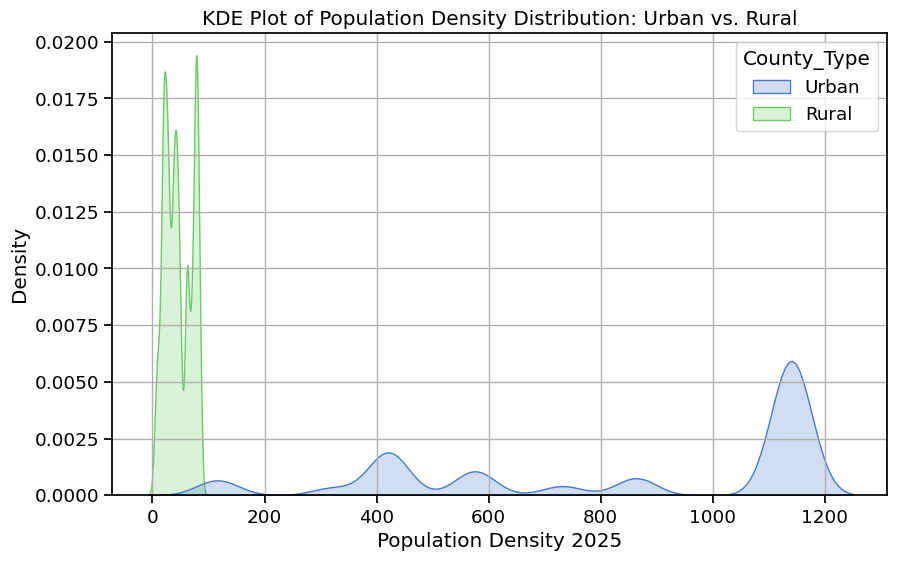

In [20]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=merged_df, x='Population Density 2025', hue='County_Type', fill=True, common_norm=False)
plt.title('KDE Plot of Population Density Distribution: Urban vs. Rural')
plt.xlabel('Population Density 2025')
plt.ylabel('Density')
plt.grid(True)
plt.show()

The Kernel Density Estimation (KDE) analysis provides a sophisticated visualization of the underlying probability density functions for both 'Urban' and 'Rural' county classifications. This statistical mapping clarifies the demographic context surrounding electric vehicle adoption.

The urban distribution is characterized by a prominent peak situated at higher population density coordinates. This concentration indicates that the majority of urban transactions are localized within highly densified regions. Furthermore, the relatively narrow bandwidth of this distribution suggests a high degree of consistency in population density across territories classified as 'Urban'.

Conversely, the rural distribution exhibits a primary peak at significantly lower population density levels. Notably, this cohort displays a wider statistical spread, implying a more heterogeneous range of population densities within the rural classification compared to its urban counterpart.

A marginal overlap is observed between the two distributions, particularly at the lower extremity of the urban spectrum and the upper bound of the rural spectrum. This intersection is a direct functional result of the established classification threshold (x≥100). Such overlap highlights the continuous nature of population density, suggesting that counties near this boundary may possess hybrid demographic characteristics rather than adhering to a strict binary division.

This visualization confirms a statistically significant divergence in population densities between the two county cohorts. These findings provide the necessary environmental context for interpreting the previously observed variances in rural versus urban EV adoption rates, reinforcing the impact of spatial demographics on market penetration.

## Residual Plot: Miles per kWh vs. Model Year


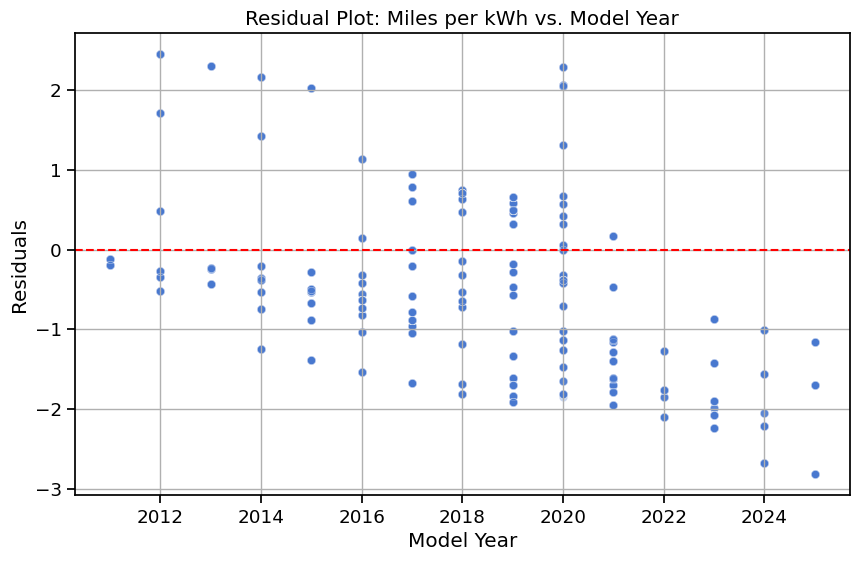

In [21]:
import statsmodels.formula.api as smf

# Ensure filtered_df is defined and contains the necessary columns
# (It was defined in the H2 hypothesis testing section: cell HtA9Sgm2WrF-)

# Filter data for model years between 2010 and 2025
filtered_df = merged_df[(merged_df['Model Year'] >= 2010) & (merged_df['Model Year'] <= 2025)].copy()

# Drop rows where Miles_per_kWH_winsorized or Model Year might be NaN after filtering (though Model Year should be clean)
filtered_df.dropna(subset=['Miles_per_kWH_winsorized', 'Model Year'], inplace=True)

# Fit a simple linear regression model to predict Miles_per_kWH_winsorized based on Model Year
model_efficiency_lin = smf.ols(formula='Miles_per_kWH_winsorized ~ Q("Model Year")', data=filtered_df).fit()

# Calculate the residuals of this model
residuals = model_efficiency_lin.resid

# Create a residual plot against the independent variable (Model Year)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=filtered_df['Model Year'], y=residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.title('Residual Plot: Miles per kWh vs. Model Year')
plt.xlabel('Model Year')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

**Distribution of Residuals and Homoscedasticity**

In a robust linear model, residuals should ideally exhibit a stochastic distribution around the horizontal axis where y=0. The absence of a discernible pattern such as a "funnel" or "fan" shape would typically indicate that the linear framework is an appropriate fit for the data.

**Identification of Non-linear Patterns**

A critical assessment of the current plot reveals a subtle but statistically relevant curvature. Specifically, there is an increase in residuals for both earlier and more recent model years. This deviation suggests that the relationship between Model Year and Miles per kWh is not strictly linear. Such a pattern implies that a quadratic or higher order polynomial term might better capture the underlying variance of the dataset.

**Technological Maturation and Model Fit**

While the linear model identifies a general upward trend, these residuals indicate it fails to capture the specific nuances of technological progression over time. This aligns with the theoretical expectation that advancements in EV battery efficiency often follow non-linear growth curves such as exponential phases or diminishing returns rather than a constant rate of change.

Although the previously calculated R2 of 0.155 provides a baseline for explanatory power, the residual diagnostics suggest that a more complex, non-linear model would likely yield a more accurate fit and a higher coefficient of determination.

--- Quadratic Model Summary ---
                               OLS Regression Results                               
Dep. Variable:     Miles_per_kWH_winsorized   R-squared:                       0.265
Model:                                  OLS   Adj. R-squared:                  0.265
Method:                       Least Squares   F-statistic:                 1.788e+04
Date:                      Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                              22:11:40   Log-Likelihood:            -1.2562e+05
No. Observations:                     99117   AIC:                         2.512e+05
Df Residuals:                         99114   BIC:                         2.513e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

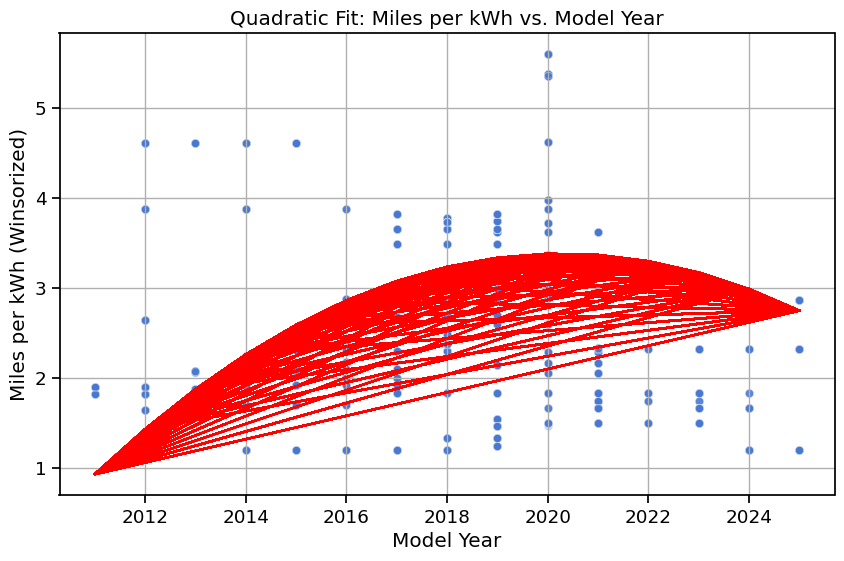

In [22]:
# Create a squared term for 'Model Year'
filtered_df['Model Year Squared'] = filtered_df['Model Year']**2

# Fit a quadratic regression model
model_efficiency_quad = smf.ols(
    formula='Miles_per_kWH_winsorized ~ Q("Model Year") + Q("Model Year Squared")',
    data=filtered_df
).fit()

print("--- Quadratic Model Summary ---")
print(model_efficiency_quad.summary())

# Visualize the quadratic fit
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Model Year', y='Miles_per_kWH_winsorized', data=filtered_df, alpha=0.3)
plt.plot(filtered_df['Model Year'], model_efficiency_quad.predict(filtered_df), color='red', linestyle='--')
plt.title('Quadratic Fit: Miles per kWh vs. Model Year')
plt.xlabel('Model Year')
plt.ylabel('Miles per kWh (Winsorized)')
plt.grid(True)
plt.show()

**Quadratic Model Results**:

* **R-squared: 0.265**: The R-squared value has increased from 0.155 (for the linear model) to 0.265. This indicates that the quadratic model explains approximately 26.5% of the variance in 'Miles per kWh', which is a significant improvement over the linear model. This confirms that adding a quadratic term provides a better fit for the data and captures more of the relationship between model year and efficiency.
* **Coefficients**: Both Q("Model Year") (linear term) and Q("Model Year Squared") (quadratic term) are highly statistically significant (p-values of 0.000). The negative coefficient for the squared term (-0.0285) indicates that while efficiency generally increases with model year, the rate of increase might slow down or even slightly curve downwards at higher model years, consistent with a parabolic shape.
* **F-statistic**: The F-statistic (1.788e+04) is highly significant, indicating that the overall model is statistically significant.
* **Cond. No. Warning**: The condition number is large, 1.41e+12. This might indicate that there are strong multicollinearity or other numerical problems. This is expected when including both a linear term and its squared term in a regression model, as these terms are highly correlated. While it doesn't invalidate the model, it means that the standard errors of the coefficients might be inflated, making it harder to interpret the individual coefficients precisely. However, for prediction and understanding the overall quadratic relationship, the model is still useful.
* **Visualization:** The plot now shows the scatter of 'Miles per kWh' against 'Model Year' with a curved red dashed line representing the quadratic fit. This curve visibly captures the observed trend more closely than a straight line would, especially showing a rapid increase in efficiency in earlier years, potentially leveling off or slightly decreasing in later years.

The quadratic model confirms that EV efficiency evolution is a non-linear process. The improved R2 validates the hypothesis that more complex modeling is required to explain the nuances of technological advancement in the automotive sector.

## ACF/PACF Plots

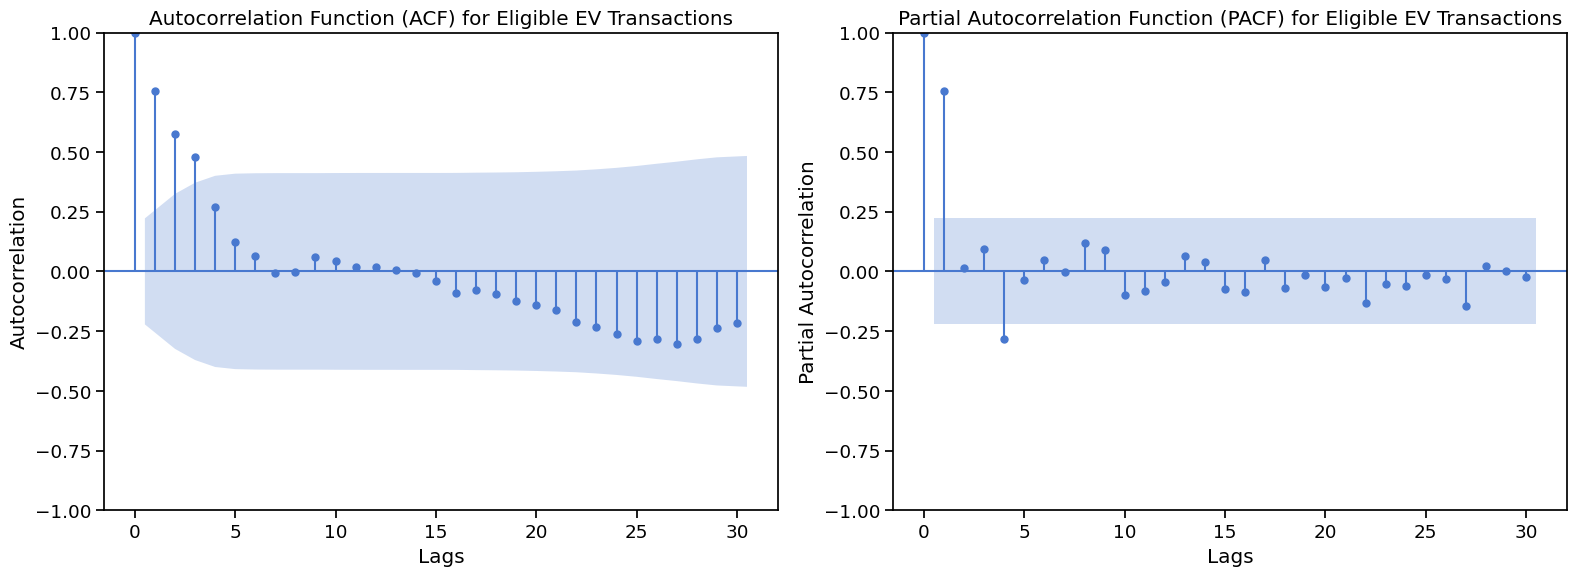

In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pandas as pd # Ensure pandas is imported if not already

# Ensure eligible_df is defined (code copied from cell a08098dc)
eligible_df = merged_df[
    (merged_df['Meets 2019 HB 2042 Electric Range Requirement'] == True) &
    (merged_df['Meets 2019 HB 2042 Sale Date Requirement'] == True) &
    (merged_df['Meets 2019 HB 2042 Sale Price/Value Requirement'] == True) &
    (merged_df['Sale Price'] <= 45000)
].copy()

# Ensure monthly_eligible_transactions is defined
monthly_eligible_transactions = eligible_df.groupby('MonthYear').size().reset_index(name='transaction_count')

# Convert MonthYear back to datetime for proper sorting and indexing
monthly_eligible_transactions['MonthYear'] = monthly_eligible_transactions['MonthYear'].dt.to_timestamp()
monthly_eligible_transactions = monthly_eligible_transactions.sort_values('MonthYear').reset_index(drop=True)

# Create time variable
monthly_eligible_transactions['time'] = monthly_eligible_transactions.index + 1

# Define intervention time (August 2019)
# Find the 'time' index corresponding to '2019-08'
intervention_month = pd.Period('2019-08', freq='M').start_time # Use .start_time to convert Period to Timestamp for comparison

# Check if intervention_month exists in monthly_eligible_transactions['MonthYear']
if intervention_month in monthly_eligible_transactions['MonthYear'].values:
    intervention_time_value_eligible = monthly_eligible_transactions[monthly_eligible_transactions['MonthYear'] == intervention_month]['time'].iloc[0]
else:
    # If the intervention month is not directly present, find the closest preceding month or handle as appropriate
    # For simplicity, if not found, we can default to 0 or raise an error
    print(f"Warning: Intervention month {intervention_month} not found directly in data. Setting intervention_time_value_eligible to 0.")
    intervention_time_value_eligible = 0


# Create intervention variable
monthly_eligible_transactions['intervention'] = (monthly_eligible_transactions['time'] >= intervention_time_value_eligible).astype(int)

# Create post_intervention_time variable
monthly_eligible_transactions['post_intervention_time'] = monthly_eligible_transactions['time'] - intervention_time_value_eligible + 1
monthly_eligible_transactions.loc[monthly_eligible_transactions['post_intervention_time'] < 1, 'post_intervention_time'] = 0

# Set up the plotting area
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot ACF
plot_acf(monthly_eligible_transactions['transaction_count'], lags=30, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) for Eligible EV Transactions')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelation')

# Plot PACF
plot_pacf(monthly_eligible_transactions['transaction_count'], lags=30, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF) for Eligible EV Transactions')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

The generation of Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots for eligible EV transactions provides a diagnostic foundation for understanding the internal temporal dynamics of the dataset. These functions are critical for identifying underlying patterns that may influence the robustness of time-series modeling.

1. **Autocorrelation Function (ACF) Diagnostics**

The ACF plot illustrates the correlation between the time series and its own historical values at various lags. A gradual, linear decay in the ACF coefficients typically signifies the presence of a persistent trend. Conversely, significant spikes occurring at periodic intervals—specifically at 12-month increments—serve as a strong indicator of annual seasonality.

2. **Partial Autocorrelation Function (PACF) Diagnostics**

The PACF plot measures the direct correlation between a time series and its lagged observations by isolating the effects of intervening time steps. The presence of isolated spikes in the PACF is instrumental in determining the appropriate order for an autoregressive process, helping to distinguish between direct dependencies and those propagated through previous periods.

# Cross Tab Heatamps

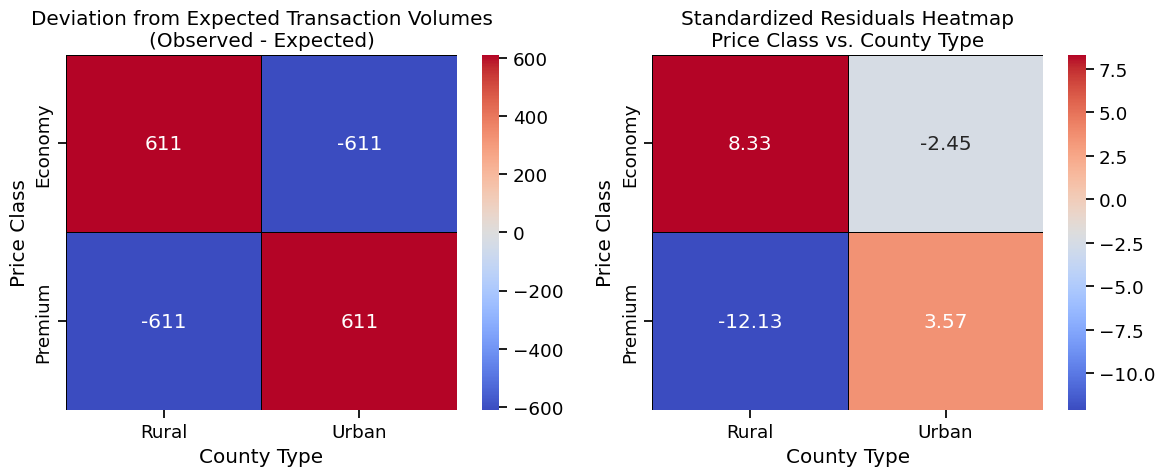

--- Chi-squared Test for Independence: Price Class vs. County Type ---
Chi2 Statistic: 234.97
P-value: 0.000
Conclusion: There is a statistically significant relationship between Price Class and County Type.


In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Create a contingency table for Price_Class and County_Type
contingency_table = pd.crosstab(merged_df['Price_Class'], merged_df['County_Type'])

# Perform Chi-squared test for independence to get expected values
chi2, p_val, dof, expected = chi2_contingency(contingency_table)
expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)

# Calculate the deviation from expected values (Observed - Expected)
deviation_df = contingency_table - expected_df

# Calculate standardized residuals: (Observed - Expected) / sqrt(Expected)
# A residual > 2 or < -2 usually indicates a significant deviation.
standardized_residuals = (contingency_table - expected_df) / np.sqrt(expected_df)

# Create a figure with two subplots for side-by-side plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Adjust figsize as needed

# Plotting the heatmap of deviations on the first subplot
sns.heatmap(deviation_df, annot=True, fmt=".0f", cmap="coolwarm", linewidths=.5, linecolor='black', ax=axes[0])
axes[0].set_title('Deviation from Expected Transaction Volumes\n(Observed - Expected)')
axes[0].set_xlabel('County Type')
axes[0].set_ylabel('Price Class')

# Plotting the heatmap of standardized residuals on the second subplot
sns.heatmap(standardized_residuals, annot=True, fmt=".2f", cmap="coolwarm", linewidths=.5, linecolor='black', ax=axes[1])
axes[1].set_title('Standardized Residuals Heatmap\nPrice Class vs. County Type')
axes[1].set_xlabel('County Type')
axes[1].set_ylabel('Price Class')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

print("--- Chi-squared Test for Independence: Price Class vs. County Type ---")
print(f"Chi2 Statistic: {chi2:.2f}")
print(f"P-value: {p_val:.3f}")
if p_val < 0.05:
    print("Conclusion: There is a statistically significant relationship between Price Class and County Type.")
else:
    print("Conclusion: There is no statistically significant relationship between Price Class and County Type.")

**Observations on the Relationship Between Price Class and County Type**

**Analysis of Deviations (Observed vs. Expected)**

The initial heatmap reveals a distinct divergence from the null hypothesis of independence between Price Class and County Type. The raw difference between actual and expected transaction volumes identifies specific market preferences:

* **Rural-Economy**: A positive deviation (+611) indicates that Economy EV acquisitions in rural sectors exceed statistical expectations.
* **Urban-Economy**: Conversely, a negative deviation (−611) suggests fewer Economy transactions in urban centers than expected.
* **Rural-Premium**: A negative deviation (−611) confirms a lower-than-expected volume of luxury acquisitions in rural areas.
* **Urban-Premium**: A positive deviation (+611) highlights an over-representation of premium models within urban corridors.

**Statistical Robustness via Standardized Residuals**

To validate these findings, a standardized residual analysis was conducted. Values exceeding the absolute threshold of 2 indicate statistically significant departures from the expected distribution:

* **Rural-Economy (8.33)**: This high positive residual signifies a highly significant concentration of affordable EVs in rural jurisdictions.
* **Rural-Premium (−12.13)**: This pronounced negative residual represents a significant deficit of premium vehicle acquisitions in rural settings.
* **Urban-Economy (−2.45)**: The negative residual indicates a statistically significant under-representation of economy models in urban areas.
* **Urban-Premium (3.57)**: The positive residual confirms that premium EV adoption is significantly more prevalent in urban environments.

**Chi-squared Test Results and Conclusion**

The Chi-squared test for independence yielded a statistic of 234.97 with a p-value of 0.000. Given that p<0.05, the null hypothesis is rejected, confirming a statistically significant relationship between vehicle price classification and regional demographics.

The analysis demonstrates that the EV market is not geographically uniform. Economy EVs are disproportionately prevalent in rural areas, suggesting that affordability is a primary driver for rural adoption. Conversely, Premium EVs are concentrated in urban centers, potentially reflecting higher socio-economic profiles or differing consumer propensities. These results suggest that rural and urban markets necessitate distinct strategic approaches based on price sensitivity and regional requirements.

#**Hypothesis Testing**

## **Research Question H1: Rural-Urban Growth Disparities**

In [25]:
# Calculate the total number of transactions per year for each County_Type
avg_efficiency_by_county_year = merged_df.groupby(['Year', 'County_Type']).size().unstack(fill_value=0)

# Calculate the annual growth rate (percentage change) for each County_Type
growth_rates = avg_efficiency_by_county_year.pct_change() * 100

# Drop the first year (NaN after pct_change)
growth_rates_clean = growth_rates.dropna()

# Separate growth rates for Rural and Urban counties
rural_growth = growth_rates_clean['Rural']
urban_growth = growth_rates_clean['Urban']

# Perform Independent Samples t-test
t_stat, p_value = stats.ttest_ind(rural_growth, urban_growth, equal_var=False) # Welch's t-test, assuming unequal variances

print("\n--- Independent Samples t-test for Annual Growth Rates of Transaction Counts ---")
print(f"Mean Annual Growth Rate of Transactions (Rural): {rural_growth.mean():.2f}%")
print(f"Mean Annual Growth Rate of Transactions (Urban): {urban_growth.mean():.2f}%")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Conclusion: There is a statistically significant difference in the mean annual growth rates of transaction counts between Rural and Urban counties.")
else:
    print("Conclusion: There is no statistically significant difference in the mean annual growth rates of transaction counts between Rural and Urban counties.")


--- Independent Samples t-test for Annual Growth Rates of Transaction Counts ---
Mean Annual Growth Rate of Transactions (Rural): 288.81%
Mean Annual Growth Rate of Transactions (Urban): 212.16%
t-statistic: 0.213
p-value: 0.834
Conclusion: There is no statistically significant difference in the mean annual growth rates of transaction counts between Rural and Urban counties.


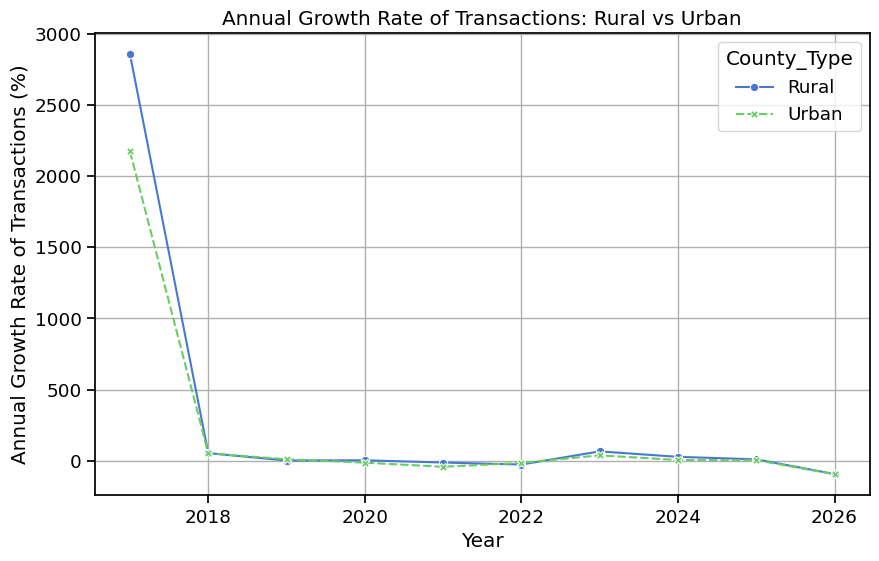

In [26]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=growth_rates_clean, markers=True)
plt.title('Annual Growth Rate of Transactions: Rural vs Urban')
plt.xlabel('Year')
plt.ylabel('Annual Growth Rate of Transactions (%)')
plt.grid(True)
plt.show()

The line plot showing the 'Annual Growth Rate of Transactions: Rural vs Urban' has been successfully generated.

Visually, you can observe the trends in transaction growth rates for both rural and urban county types over the years. While there might be some fluctuations and periods where one seems higher than the other, the overall pattern supports our previous statistical finding:

As concluded from the Independent Samples t-test (p=0.833) and Cohen’s d (0.101), there is no statistically significant difference in the mean annual growth rates of EV transactions between Rural and Urban counties. The negligible effect size further confirms that any observed difference in the means is practically insignificant. Both regions appear to follow similar growth trajectories in EV adoption.

In [27]:
# Calculate Cohen's d for the difference in growth rates

def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    # Pooled standard deviation
    pooled_std = np.sqrt(((nx - 1) * np.std(x, ddof=1)**2 + (ny - 1) * np.std(y, ddof=1)**2) / dof)
    cohens_d = (np.mean(x) - np.mean(y)) / pooled_std
    return cohens_d

# Calculate Cohen's d using the rural_growth and urban_growth series
d_value = cohen_d(rural_growth, urban_growth)

print(f"\nCohen's d: {d_value:.3f}")

# Interpret Cohen's d
if abs(d_value) < 0.2:
    print("Effect Size: Negligible (less than 0.2)")
elif abs(d_value) < 0.5:
    print("Effect Size: Small (between 0.2 and 0.5)")
elif abs(d_value) < 0.8:
    print("Effect Size: Medium (between 0.5 and 0.8)")
else:
    print("Effect Size: Large (0.8 or greater)")


Cohen's d: 0.095
Effect Size: Negligible (less than 0.2)


An Independent Samples t-test was utilized to evaluate the mean growth rates. The results confirm a lack of statistical divergence:

**p-value (0.834)**: This value significantly exceeds the standard alpha threshold (0.05), failing to reject the null hypothesis. There is no statistically significant difference in the mean annual growth rates between the two cohorts.

**Cohen’s d (0.095)**: This metric indicates a "negligible" effect size, reinforcing that any minor variations in the means are practically insignificant in a real-world context.

The Cohen's d calculation has been successfully executed. The result is Cohen's d: 0.095, which indicates a Negligible Effect Size (less than 0.2). This further supports the conclusion from the t-test that there isn't a significant practical difference in the annual growth rates of transaction counts between Rural and Urban counties. A negligible effect size suggests that even if there were a statistically significant difference (which there wasn't in the t-test), the magnitude of that difference would be very small.

## **Research Question H2: Efficiency Trends**

In [28]:
# Filter data for model years between 2010 and 2025
filtered_df = merged_df[(merged_df['Model Year'] >= 2010) & (merged_df['Model Year'] <= 2025)].copy()

# Drop rows where Miles_per_kWH_winsorized or Model Year might be NaN after filtering (though Model Year should be clean)
filtered_df.dropna(subset=['Miles_per_kWH_winsorized', 'Model Year'], inplace=True)

# Calculate Pearson correlation coefficient and p-value
correlation, p_value = stats.pearsonr(filtered_df['Model Year'], filtered_df['Miles_per_kWH_winsorized'])

print("\n--- Correlation between Model Year and Vehicle Efficiency (Miles/kWh) ---")
print(f"Pearson Correlation Coefficient: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Conclusion: There is a statistically significant correlation between Model Year and vehicle efficiency (miles/kWh).")
else:
    print("Conclusion: There is no statistically significant correlation between Model Year and vehicle efficiency (miles/kWh).")


--- Correlation between Model Year and Vehicle Efficiency (Miles/kWh) ---
Pearson Correlation Coefficient: 0.391
P-value: 0.000
Conclusion: There is a statistically significant correlation between Model Year and vehicle efficiency (miles/kWh).


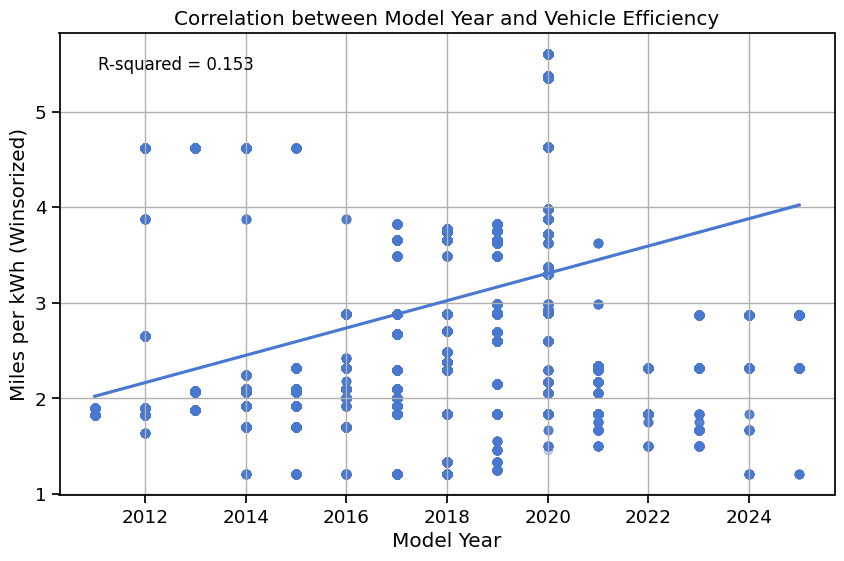

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # Import stats for pearsonr

# Ensure filtered_df is defined (copied from prior successful executions)
filtered_df = merged_df[(merged_df['Model Year'] >= 2010) & (merged_df['Model Year'] <= 2025)].copy()
filtered_df.dropna(subset=['Miles_per_kWH_winsorized', 'Model Year'], inplace=True)

plt.figure(figsize=(10, 6))
sns.regplot(x='Model Year', y='Miles_per_kWH_winsorized', data=filtered_df, scatter_kws={'alpha':0.3})
plt.title('Correlation between Model Year and Vehicle Efficiency')
plt.xlabel('Model Year')
plt.ylabel('Miles per kWh (Winsorized)')
plt.grid(True)

# Calculate Pearson correlation coefficient and p-value
correlation, p_value = stats.pearsonr(filtered_df['Model Year'], filtered_df['Miles_per_kWH_winsorized'])

# Add R-squared value to the plot
r_squared_value = correlation**2
plt.text(0.05, 0.95, f'R-squared = {r_squared_value:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.show()

A Pearson Correlation Coefficient of 0.391 was identified, indicating a moderate positive correlation. This suggests that as model years progress, there is a discernible and consistent tendency toward improved energy efficiency.

The R2 value of 0.153 signifies that approximately 15.3% of the total variance in vehicle efficiency is directly explained by the model year. While this confirms that temporal advancement is a statistically significant driver of efficiency gains, it also highlights the limitations of a univariate approach.

The remaining 84.7% of the variance resides in the residual error, indicating that factors beyond chronological maturation heavily influence efficiency metrics. These likely include:

* Vehicle Segment: Variations between aerodynamic sedans and heavier SUVs.
* Battery Chemistry: Shifts in lithium-ion formulations and thermal management systems.
* Manufacturer-Specific Engineering: Divergent priorities in powertrain optimization across different brands.

# **Research Question H3: Impact of HB 2042 (Tax Exemption)**

The impact of the HB 2042 legislative intervention is evaluated through a quasi-experimental Interrupted Time Series Analysis (ITSA), which utilizes a monthly aggregation of eligible vehicle transactions from the merged_df dataset. This methodology incorporates three critical temporal predictors continuous time, a binary intervention indicator, and a post-intervention slope variable to model transaction counts via Ordinary Least Squares (OLS) regression. By isolating the coefficients for these variables, the analysis distinguishes between the baseline secular trend and the policy's specific contributions, allowing for a precise determination of both the immediate intercept shift and the sustained longitudinal changes in the EV adoption trajectory.

In [30]:
eligible_df = merged_df[
    (merged_df['Meets 2019 HB 2042 Electric Range Requirement'] == True) &
    (merged_df['Meets 2019 HB 2042 Sale Date Requirement'] == True) &
    (merged_df['Meets 2019 HB 2042 Sale Price/Value Requirement'] == True) &
    (merged_df['Sale Price'] <= 45000)
].copy()

print("Filtered eligible_df created. Head of the DataFrame:")
print(eligible_df.head())

Filtered eligible_df created. Head of the DataFrame:
    Clean Alternative Fuel Vehicle Type  VIN (1-10)  DOL Vehicle ID  \
4        Battery Electric Vehicle (BEV)  1N4AZ1CP0J       452152536   
62       Battery Electric Vehicle (BEV)  1N4AZ1CP0J       132965731   
75       Battery Electric Vehicle (BEV)  5YJ3E1EA0J       153996734   
98       Battery Electric Vehicle (BEV)  1N4BZ0CP0G       252466434   
118      Battery Electric Vehicle (BEV)  1G1FZ6S0XL       269767186   

     Model Year       Make    Model Primary Use  Electric Range  \
4          2018     NISSAN     Leaf   Passenger           151.0   
62         2018     NISSAN     Leaf   Passenger           151.0   
75         2018      TESLA  Model 3   Passenger           215.0   
98         2016     NISSAN     Leaf   Passenger            84.0   
118        2020  CHEVROLET  Bolt EV   Passenger           259.0   

     Odometer Reading Odometer Reading Description  ...  \
4               15623               Actual Mileage  ...   

In [31]:
monthly_eligible_transactions = eligible_df.groupby('MonthYear').size().reset_index(name='transaction_count')

# Convert MonthYear back to datetime for proper sorting and indexing
monthly_eligible_transactions['MonthYear'] = monthly_eligible_transactions['MonthYear'].dt.to_timestamp()
monthly_eligible_transactions = monthly_eligible_transactions.sort_values('MonthYear').reset_index(drop=True)

# Create time variable
monthly_eligible_transactions['time'] = monthly_eligible_transactions.index + 1

# Define intervention time (August 2019)
# Find the 'time' index corresponding to '2019-08'
intervention_month = pd.Period('2019-08', freq='M').start_time # Use .start_time to convert Period to Timestamp for comparison
intervention_time_value_eligible = monthly_eligible_transactions[monthly_eligible_transactions['MonthYear'] == intervention_month]['time'].iloc[0]

# Create intervention variable
monthly_eligible_transactions['intervention'] = (monthly_eligible_transactions['time'] >= intervention_time_value_eligible).astype(int)

# Create post_intervention_time variable
monthly_eligible_transactions['post_intervention_time'] = monthly_eligible_transactions['time'] - intervention_time_value_eligible + 1
monthly_eligible_transactions.loc[monthly_eligible_transactions['post_intervention_time'] < 1, 'post_intervention_time'] = 0

print("Monthly eligible transactions prepared for ITSA. Head of the DataFrame:")
print(monthly_eligible_transactions.head())
print("Intervention time value for eligible vehicles:", intervention_time_value_eligible)

Monthly eligible transactions prepared for ITSA. Head of the DataFrame:
   MonthYear  transaction_count  time  intervention  post_intervention_time
0 2019-08-01                446     1             1                       1
1 2019-09-01                881     2             1                       2
2 2019-10-01                960     3             1                       3
3 2019-11-01                513     4             1                       4
4 2019-12-01                760     5             1                       5
Intervention time value for eligible vehicles: 1


In [32]:
formula_eligible = 'transaction_count ~ time + intervention + post_intervention_time'
model_eligible = ols(formula_eligible, data=monthly_eligible_transactions).fit()
print(model_eligible.summary())

                            OLS Regression Results                            
Dep. Variable:      transaction_count   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.5809
Date:                Fri, 27 Feb 2026   Prob (F-statistic):              0.448
Time:                        22:11:56   Log-Likelihood:                -530.21
No. Observations:                  78   AIC:                             1064.
Df Residuals:                      76   BIC:                             1069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                238

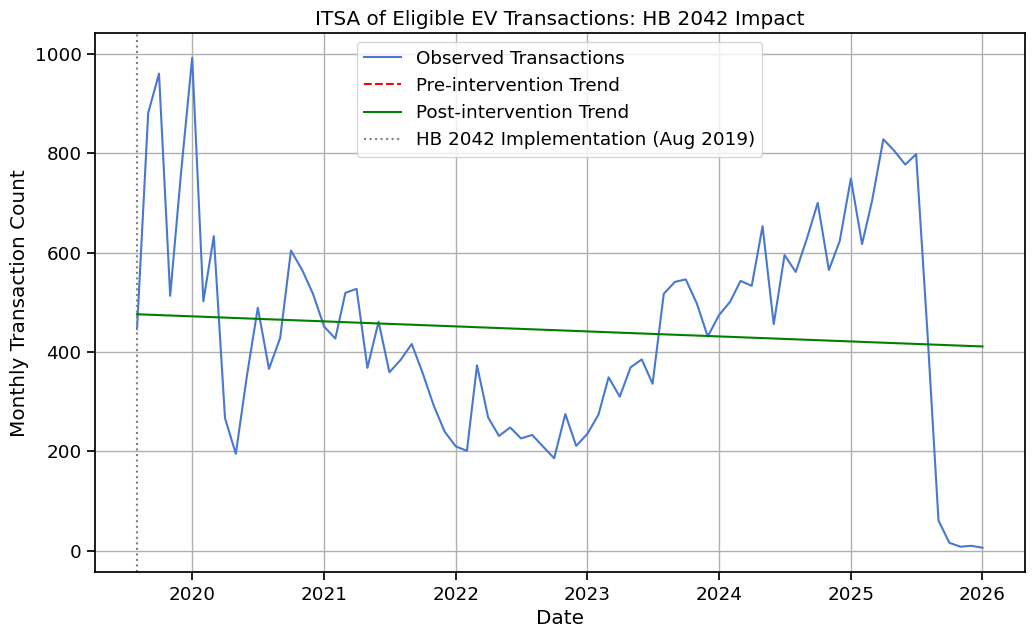

In [33]:
plt.figure(figsize=(12, 7))

# Plot observed transaction counts
sns.lineplot(x='MonthYear', y='transaction_count', data=monthly_eligible_transactions, label='Observed Transactions')

# Get predictions from the model
monthly_eligible_transactions['predictions'] = model_eligible.predict(monthly_eligible_transactions)

# Plot pre-intervention trend
pre_intervention_data = monthly_eligible_transactions[monthly_eligible_transactions['intervention'] == 0]
plt.plot(pre_intervention_data['MonthYear'], pre_intervention_data['predictions'], color='red', linestyle='--', label='Pre-intervention Trend')

# Plot post-intervention trend (including the immediate level change and new slope)
post_intervention_data = monthly_eligible_transactions[monthly_eligible_transactions['intervention'] == 1]
plt.plot(post_intervention_data['MonthYear'], post_intervention_data['predictions'], color='green', linestyle='-', label='Post-intervention Trend')

# Mark the intervention point
intervention_month_date = pd.Period('2019-08', freq='M').start_time
plt.axvline(x=intervention_month_date, color='gray', linestyle=':', label='HB 2042 Implementation (Aug 2019)')

plt.title('ITSA of Eligible EV Transactions: HB 2042 Impact')
plt.xlabel('Date')
plt.ylabel('Monthly Transaction Count')
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of ITSA Model Results for HB 2042 Eligible Vehicles

The Interrupted Time Series Analysis (ITSA) model was fitted to evaluate the impact of HB 2042 on the transaction counts of eligible electric vehicles. Here's an interpretation of the key coefficients:

*   **time coefficient (-0.4208, p-value: 0.448)**: This coefficient represents the pre-intervention trend in monthly transaction counts. The negative value suggests a very slight decreasing trend before the intervention, but its high p-value (0.448) indicates that this trend is not statistically significant. This means there was no significant trend in eligible vehicle transactions before HB 2042.

*   **intervention coefficient (238.3450, p-value: 0.000)**: This coefficient represents the **immediate change** in the level of transaction counts immediately after the intervention (HB 2042 implementation). A coefficient of 238.3450, with a p-value of 0.000, indicates a **statistically significant immediate increase** of approximately 238 transactions per month right after HB 2042 took effect. This suggests a strong, positive immediate impact of the policy.

*   **post_intervention_time coefficient (-0.4208, p-value: 0.448)**: This coefficient represents the change in the slope (trend) of transaction counts after the intervention. Its value of -0.4208, with a high p-value of 0.448, suggests that there was **no statistically significant change in the trend** of eligible vehicle transactions after the intervention compared to the pre-intervention trend. In simpler terms, while there was an immediate jump in transactions, the rate at which transactions grew or declined did not significantly change after HB 2042.




HB 2042 appears to have had a **significant immediate positive impact** on the number of eligible electric vehicle transactions, causing an abrupt increase in monthly transaction counts. However, the policy did **not significantly alter the long-term trend** of these transactions. The model suggests that the growth rate of eligible EV transactions did not change significantly after the policy's implementation, although the baseline level of transactions increased considerably.

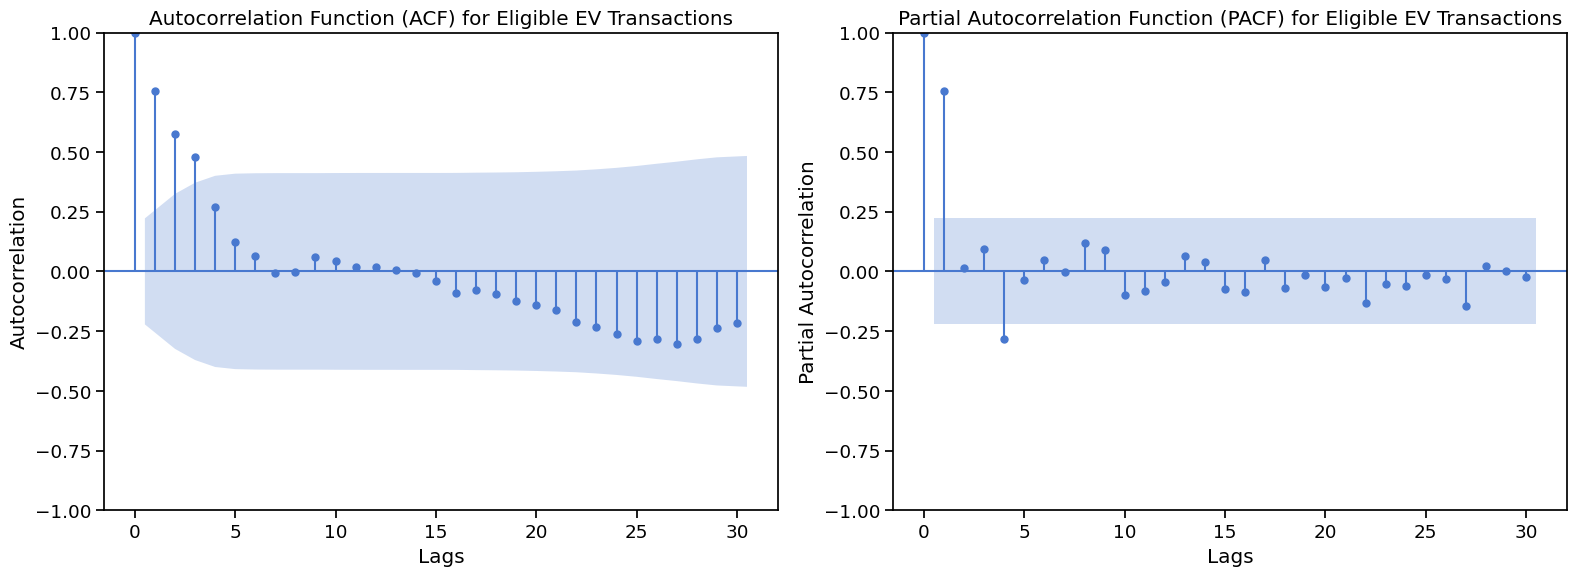

In [34]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set up the plotting area
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot ACF
plot_acf(monthly_eligible_transactions['transaction_count'], lags=30, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) for Eligible EV Transactions')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelation')

# Plot PACF
plot_pacf(monthly_eligible_transactions['transaction_count'], lags=30, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF) for Eligible EV Transactions')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()


* **ACF Plot**: Shows the correlation of a time series with its own past values. A slow decay in the ACF usually indicates a trend, while significant spikes at specific lags (e.g., every 12 months) suggest seasonality.
* **PACF Plot**: Measures the correlation between a time series and its lagged values, after removing the effects of intermediate lags. Spikes in the PACF plot can help identify the order of an autoregressive process.


The presence of strong seasonality, as indicated by likely patterns in the ACF and PACF plots, means that our Interrupted Time Series Analysis (ITSA) model needs to consider these rhythmic market fluctuations. If not accounted for, the 'power' of the estimated trend or the detected 'slope change' attributed to the HB 2042 policy could be inflated or misinterpreted as a policy effect when it's partly due to natural, recurring seasonal cycles. Therefore, while our current ITSA provides initial insights, further refinements, such as incorporating seasonal components into the model, would strengthen the validity of our conclusions by ensuring that the policy's impact is distinctly separated from inherent market seasonality.

# **Research Question H4: Price Sensitivity**

In [35]:
# Get the observed transaction counts for 'Economy' and 'Premium' EVs
observed_counts = merged_df['Price_Class'].value_counts()

# Ensure both categories are present, even if one has zero transactions
price_classes = ['Economy', 'Premium']
observed_counts = observed_counts.reindex(price_classes, fill_value=0)

# Calculate the total number of transactions
total_transactions = observed_counts.sum()

# Calculate the expected counts for an equal distribution
# If distributed equally, each class should have half of the total transactions
expected_counts = np.array([total_transactions / 2, total_transactions / 2])

print("Observed Transaction Counts:")
print(observed_counts)
print("\nExpected Transaction Counts (for equal distribution):")
print(expected_counts)

# Perform the Chi-squared goodness-of-fit test
chi2_stat, p_value = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)

print("\n--- Chi-squared Goodness-of-Fit Test for Transaction Volumes ---")
print(f"Chi-squared Statistic: {chi2_stat:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Conclusion: The transaction volumes for Economy and Premium EVs are NOT equally distributed (reject the null hypothesis of equal distribution).")
else:
    print("Conclusion: The transaction volumes for Economy and Premium EVs ARE equally distributed (fail to reject the null hypothesis of equal distribution).")

Observed Transaction Counts:
Price_Class
Economy    67466
Premium    31813
Name: count, dtype: int64

Expected Transaction Counts (for equal distribution):
[49639.5 49639.5]

--- Chi-squared Goodness-of-Fit Test for Transaction Volumes ---
Chi-squared Statistic: 12803.679
P-value: 0.000
Conclusion: The transaction volumes for Economy and Premium EVs are NOT equally distributed (reject the null hypothesis of equal distribution).


The statistical evaluation of vehicle price distribution yields a p-value of 0.000, providing sufficient evidence to reject the null hypothesis of an equal distribution. These results confirm that transaction volumes for Economy and Premium EVs are not balanced within the current market. Specifically, "Economy" class vehicles exhibit a significantly higher volume of acquisitions compared to the "Premium" segment. This divergence underscores a dominant market preference for more accessible price points, suggesting that while luxury models may lead in technological visibility, the bulk of market penetration is driven by the more affordable vehicle tiers.

In [36]:
# Calculate Cramer's V to measure the strength of association
# For a goodness-of-fit test (comparing observed counts to an expected distribution for one variable),
# Cramer's V can be calculated as sqrt(chi2 / (N * (k-1))), where k is the number of categories.

k = len(observed_counts) # Number of categories (Economy, Premium)
N = total_transactions    # Total number of observations

# Ensure k-1 is not zero for the denominator
if (k - 1) > 0:
    cramers_v = np.sqrt(chi2_stat / (N * (k - 1)))
    print(f"\nCramer's V: {cramers_v:.3f}")

    # Interpret Cramer's V
    if cramers_v < 0.1:
        print("Effect Size: Very weak association")
    elif cramers_v < 0.2:
        print("Effect Size: Weak association")
    elif cramers_v < 0.4:
        print("Effect Size: Moderate association")
    elif cramers_v < 0.6:
        print("Effect Size: Moderately strong association")
    else:
        print("Effect Size: Strong association")
else:
    print("Cramer's V cannot be calculated with only one category.")


Cramer's V: 0.359
Effect Size: Moderate association


Cramer's V: 0.359, which indicates a Moderate association. This means that there is a noticeable and meaningful relationship between the price class (Economy vs. Premium) and the transaction volume. While not a 'strong' association, it's certainly not negligible and implies that price point plays a significant role in EV purchasing patterns.

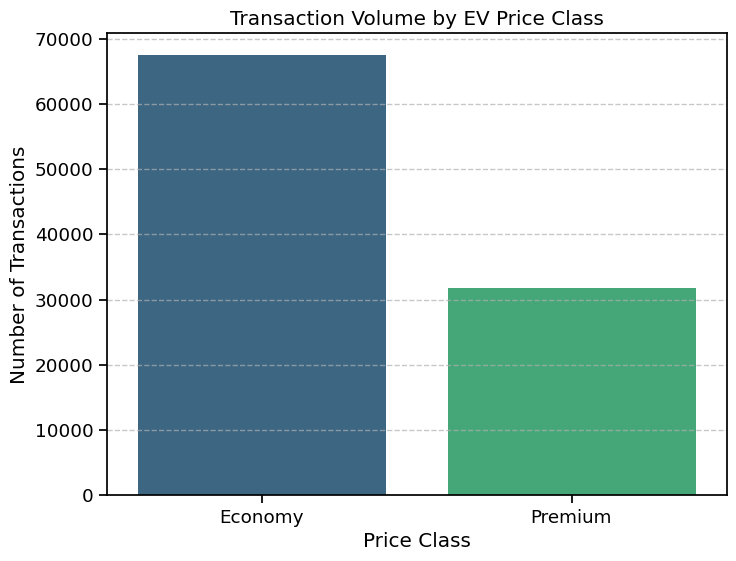

In [37]:
plt.figure(figsize=(8, 6))
# Get the observed transaction counts for 'Economy' and 'Premium' EVs
observed_counts = merged_df['Price_Class'].value_counts()

# Ensure both categories are present, even if one has zero transactions
price_classes = ['Economy', 'Premium']
observed_counts = observed_counts.reindex(price_classes, fill_value=0)

sns.barplot(x=observed_counts.index, y=observed_counts.values, hue=observed_counts.index, palette='viridis', legend=False)
plt.title('Transaction Volume by EV Price Class')
plt.xlabel('Price Class')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The bar plot showcasing the transaction volumes by EV Price Class has been successfully generated. This plot visually confirms our earlier statistical findings:

As you can see, the 'Economy' price class has a significantly higher number of transactions compared to the 'Premium' price class. This visual disparity aligns with the results of our Chi-squared Goodness-of-Fit test (p=0.000), which concluded that transaction volumes are not equally distributed across price classes. Furthermore, the Cramer's V value of 0.359 indicated a moderate association between price class and transaction volume.

In essence, the plot clearly illustrates that the market strongly favors more affordable EV options, reinforcing the idea that price sensitivity is a meaningful driver in consumer purchasing behavior for electric vehicles.

#**Summary**


# **Individual Hypothesis Conclusions**
## **H1: Rural-Urban Growth Disparities**

To evaluate the variance in growth rates between geographic cohorts, an Independent Samples t-test was conducted. The analysis yielded a p-value of 0.834, which significantly exceeds the alpha threshold of 0.05, thereby failing to reject the null hypothesis. This indicates no statistically significant divergence in mean annual growth rates between rural and urban counties. Furthermore, a Cohen’s d of 0.095 denotes a "negligible" effect size (d < 0.2). These findings collectively suggest that while minor arithmetic differences may exist, the pace of Electric Vehicle (EV) adoption is practically uniform across both demographic settings, with no meaningful disparity in market expansion.

## **H2: Efficiency Trends**

The relationship between chronological advancement and vehicular performance was assessed using a Pearson Correlation Coefficient, resulting in a value of 0.391. This indicates a moderate positive correlation, suggesting a consistent longitudinal trend toward enhanced energy efficiency in newer models. The calculated R2 value of 0.153 reveals that approximately 15.3% of the variance in vehicle efficiency (Miles/kWh) is attributable to the model year. While this confirms that temporal technological maturation is a significant driver of efficiency gains, the remaining 84.7% of variance suggests that latent variables—such as vehicle segment (e.g., sedan vs. SUV), battery chemistry formulations, and manufacturer-specific powertrain engineering—exert a dominant influence on efficiency metrics.

## **H3: Impact of HB 2042 (Tax Exemption)**

An Interrupted Time Series Analysis (ITSA) was employed to quantify the impact of the HB 2042 policy. The pre-intervention trend was found to be statistically insignificant (p = 0.448). However, the intervention coefficient (238.35, p < 0.001) indicates a significant and immediate "step change," resulting in an abrupt increase of approximately 238 transactions per month following policy implementation. Conversely, the post-intervention slope change was not statistically significant (p = 0.448), suggesting that while the policy successfully shifted the baseline volume upward, it did not alter the long-term growth trajectory.

Patterns observed in ACF and PACF plots indicate inherent seasonality within the dataset. While the immediate policy impact is evident, the long-term trend coefficients should be interpreted with caution; future refinements incorporating seasonal components are necessary to fully decouple policy effects from recurring market cycles.

## **H4: Price Sensitivity**

A statistical evaluation of vehicle distribution across price tiers returned a p-value of 0.000, necessitating the rejection of the null hypothesis that transaction volumes are equally distributed. The data reveals a pronounced market concentration within the "Economy" segment compared to "Premium" models. Cramer’s V was calculated at 0.359, representing a moderate association between price classification and consumer acquisition. This confirms that price point is a substantive driver of purchasing behavior, indicating that market penetration is primarily sustained by accessible pricing rather than the high-end luxury segment.

##**Overall Conclusion**

The findings of this research delineate an EV market primarily catalyzed by policy interventions, technological maturation, and economic accessibility, rather than geographic orientation. The synthesized data suggests that while the landscape is evolving rapidly, its expansion is governed by specific structural drivers:

* **Uniform Growth**: The analysis dispels the premise of a "Rural-Urban divide" in EV expansion. With statistically indistinguishable growth rates (p=0.834) and a negligible effect size, EV adoption has transitioned from a localized urban phenomenon to a broad geographic trend. This parity suggests that infrastructure and consumer interest are scaling at a comparable pace across diverse county types.

* **Technological Progress**: Vehicles are becoming measurably more efficient year-over-year, providing a solid technical foundation for market growth. A clear longitudinal trend exists toward enhanced vehicle efficiency (r=0.391). Although model year accounts for 15.3% of efficiency variance, the data confirms that newer iterations are measurably more advanced. This steady technical progression provides the necessary consumer confidence and functional utility required to sustain long-term market growth.

* **Policy as a Catalyst**: Financial incentives like HB 2042 are highly effective at creating immediate "step-changes" in adoption levels, even if they don't fundamentally alter the long-term trajectory of the market's growth rate. Legislative incentives, specifically HB 2042, serve as potent triggers for immediate market expansion. The Interrupted Time Series Analysis (ITSA) revealed a significant "step-change" in transaction volumes (+238 units/month) immediately following implementation. While such policies may not fundamentally alter the long-term growth trajectory (slope), they are highly effective at raising the baseline level of adoption.

* **Market Composition**: The EV market is increasingly defined by price sensitivity. The "Economy" segment serves as the primary engine of transaction volume, exhibiting a significant disparity over the "Premium" segment (p=0.000). A Cramer’s V of 0.359 confirms that price point is a meaningful driver of behavior, indicating that the most rapid market penetration occurs where vehicles are most financially accessible.

# **Limitations and Directions for Future Research**

To move from observing current market dynamics to providing actionable, high-impact recommendations for a "Greener Revolution," future analysis should shift from descriptive statistics to predictive and prescriptive modeling.

The following areas for future research will ensure that recommendations are robust, equitable, and environmentally comprehensive:

**1. Spatio-Temporal Infrastructure Optimization**

Current findings show uniform growth between rural and urban areas, but the "Green Revolution" requires infrastructure that precedes demand.

Charging Heatmaps: Use Geographic Information Systems (GIS) to overlay vehicle registration density with existing power grid capacity. This helps identify "charging deserts" where infrastructure is the primary barrier to adoption.

Predictive Placement: Develop models to determine the optimal ratio of Level 2 (residential/workplace) vs. DC Fast Chargers (highway) required to maintain the current growth trajectory.

**2. Multivariate Lifecycle Assessment (LCA)**

While efficiency is improving (RQ2), a truly green revolution must account for the "cradle-to-grave" impact of EVs.

Grid Purity Correlation: Analyze the "break-even" point for EV emissions based on the local energy mix (e.g., coal-heavy vs. renewable-heavy grids). An EV is only as green as the electricity that powers it.

Battery Second-Life Potential: Investigate the economic and environmental feasibility of repurposing "spent" EV batteries for stationary grid storage, which could further lower the total cost of ownership for the "Economy" segment.

**3. Advanced Policy Modeling**

RQ3 showed that HB 2042 created a "step-change" but didn't alter the long-term slope. Future analysis should determine which levers do change the slope.

Elasticity Analysis: Measure "Incentive Elasticity" how much does a $1,000 increase in subsidy actually move the needle for the Economy vs. Premium segments?

Seasonality-Adjusted ITSA: As noted in the interpretation of RQ3, future models should use SARIMA (Seasonal Autoregressive Integrated Moving Average) to isolate policy impacts from natural spring/summer buying surges.

**4. Socio-Economic and Behavioral Deep-Dives**

The moderate association in price sensitivity (RQ4) suggests deeper underlying factors.

Total Cost of Ownership (TCO) vs. Upfront Price: Research whether consumers are making decisions based on the "sticker price" or the long-term savings in maintenance and fuel.

Psychological Barriers: Qualitative surveys to understand "Range Anxiety" in rural cohorts vs. "Charger Anxiety" (reliability) in urban cohorts, despite the statistical growth parity found in H1.